In [35]:
import pandas as pd

In [57]:
df = pd.read_csv("../data/data.csv")

In [58]:
df.head()

,oem,year_report,month_report,level_0_country,level_1_region_name,level_2_district_postcode,level_2_district_town_name,level_3_postcode_sector_hyperlocal,model_class,model_class_specific,body_type,fuel_type,doors,Energy_Source,vehicle_count
0,ASTON MARTIN,2024,4,Northern Ireland,Magherafelt,BT45,NaN,BT458,DB11,V12,SPORTCOUPE,PETROL,2,NORMAL,1
1,ASTON MARTIN,2024,1,England,Salford,M28,Walkden,M282,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
2,ASTON MARTIN,2024,3,England,Cambridgeshire,CB7,Soham,CB75,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
3,ASTON MARTIN,2024,4,England,Leicester,LE1,Leicester,LE17,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1
4,ASTON MARTIN,2024,4,England,Leeds,LS1,NaN,LS14,DB12,V8,SPORTCOUPE,PETROL,2,NORMAL,1


In [ ]:
# Fill NA values with "N/A" for specific geographic columns
geo_columns = ['level_1_region_name', 'level_2_district_postcode',
       'level_2_district_town_name', 'level_3_postcode_sector_hyperlocal']

df[geo_columns] = df[geo_columns].fillna("N/A")

# Map body types to a standardized set
mapping_body_types = {'SPORTCOUPE':'SPORTSCOUPE', 
                      'CABRIO':'CABRIO', 
                'SUV':'SUV', 
                'HATCHBACK':'ESTATE', 
                'COUPE':'COUPE', 
                'SEDAN':'SEDAN',
                'ESTATE':'ESTATE', 
                'SUC':'SUV', 
                'CAPRIO':'CABRIO', 
                'MPV':'MPV'}

df["body_type"] = df["body_type"].map(mapping_body_types)

In [68]:
levels

('country',
 ['level_0_country'],
 'district',
 ['level_0_country',
  'level_1_region_name',
  'level_2_district_postcode',
  'level_2_district_town_name'])

In [74]:
levels = (("country", ['level_0_country']), 
         ("district", ['level_0_country',
                     'level_1_region_name', 'level_2_district_postcode',
                     'level_2_district_town_name']))


time_cols = ['year_report', 'month_report']
car_cols = ['body_type', 'fuel_type']

dfs_market_share = {}

for level, level_cols in levels:

       print(f"Processing market share for level: {level}")

       total_count_id_district_cols = time_cols + level_cols + car_cols

       df['total_vehicle_count_id'] = df[total_count_id_district_cols].apply(lambda x: '_'.join(x.astype(str)), axis=1)

       market_share_id_cols = ['oem'] + time_cols + level_cols + car_cols 

       df['market_share_id'] = df[market_share_id_cols].apply(lambda x: '_'.join(x.astype(str)), axis=1)

       # calculate monthly market share per OEM
       df[f"total_vehicles_{level}"] = df.groupby(total_count_id_district_cols)["vehicle_count"].transform("sum")
       df[f"total_vehicles_{level}_oem"] = df.groupby(market_share_id_cols)["vehicle_count"].transform("sum")

       df_market_share = df[['total_vehicle_count_id','market_share_id'] + market_share_id_cols + [f'total_vehicles_{level}', f'total_vehicles_{level}_oem']].copy()

       # Create monthly market share per OEM
       df_market_share["year_month"] = pd.to_datetime(df_market_share["year_report"].astype(str) + "-" + df_market_share['month_report'].astype(str), format="%Y-%m")

       df_market_share[f'market_share_{level}'] = df_market_share[f'total_vehicles_{level}_oem'] / df_market_share[f'total_vehicles_{level}']

       dfs_market_share[level] = df_market_share


Processing market share for level: country
Processing market share for level: district


In [75]:
dfs_market_share['country'].head()

,total_vehicle_count_id,market_share_id,oem,year_report,month_report,level_0_country,body_type,fuel_type,total_vehicles_country,total_vehicles_country_oem,year_month,market_share_country
0,2024_4_Northern Ireland_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_Northern Ireland_SPORTSCOU...,ASTON MARTIN,2024,4,Northern Ireland,SPORTSCOUPE,PETROL,13.0,1.0,2024-04-01,0.076923
1,2024_1_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_1_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,1,England,SPORTSCOUPE,PETROL,527.0,66.0,2024-01-01,0.125237
2,2024_3_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_3_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,3,England,SPORTSCOUPE,PETROL,885.0,79.0,2024-03-01,0.089266
3,2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,4,England,SPORTSCOUPE,PETROL,426.0,27.0,2024-04-01,0.063380
4,2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_England_SPORTSCOUPE_PETROL,ASTON MARTIN,2024,4,England,SPORTSCOUPE,PETROL,426.0,27.0,2024-04-01,0.063380


In [76]:
dfs_market_share['district'].head()

,total_vehicle_count_id,market_share_id,oem,year_report,month_report,level_0_country,level_1_region_name,level_2_district_postcode,level_2_district_town_name,body_type,fuel_type,total_vehicles_district,total_vehicles_district_oem,year_month,market_share_district
0,2024_4_Northern Ireland_Magherafelt_BT45_N/A_S...,ASTON MARTIN_2024_4_Northern Ireland_Magherafe...,ASTON MARTIN,2024,4,Northern Ireland,Magherafelt,BT45,N/A,SPORTSCOUPE,PETROL,2.0,1.0,2024-04-01,0.500000
1,2024_1_England_Salford_M28_Walkden_SPORTSCOUPE...,ASTON MARTIN_2024_1_England_Salford_M28_Walkde...,ASTON MARTIN,2024,1,England,Salford,M28,Walkden,SPORTSCOUPE,PETROL,3.0,1.0,2024-01-01,0.333333
2,2024_3_England_Cambridgeshire_CB7_Soham_SPORTS...,ASTON MARTIN_2024_3_England_Cambridgeshire_CB7...,ASTON MARTIN,2024,3,England,Cambridgeshire,CB7,Soham,SPORTSCOUPE,PETROL,1.0,1.0,2024-03-01,1.000000
3,2024_4_England_Leicester_LE1_Leicester_SPORTSC...,ASTON MARTIN_2024_4_England_Leicester_LE1_Leic...,ASTON MARTIN,2024,4,England,Leicester,LE1,Leicester,SPORTSCOUPE,PETROL,2.0,1.0,2024-04-01,0.500000
4,2024_4_England_Leeds_LS1_N/A_SPORTSCOUPE_PETROL,ASTON MARTIN_2024_4_England_Leeds_LS1_N/A_SPOR...,ASTON MARTIN,2024,4,England,Leeds,LS1,N/A,SPORTSCOUPE,PETROL,2.0,1.0,2024-04-01,0.500000


In [77]:
fact_market_share_country = dfs_market_share['country'].copy()
fact_market_share_district = dfs_market_share['district'].copy()

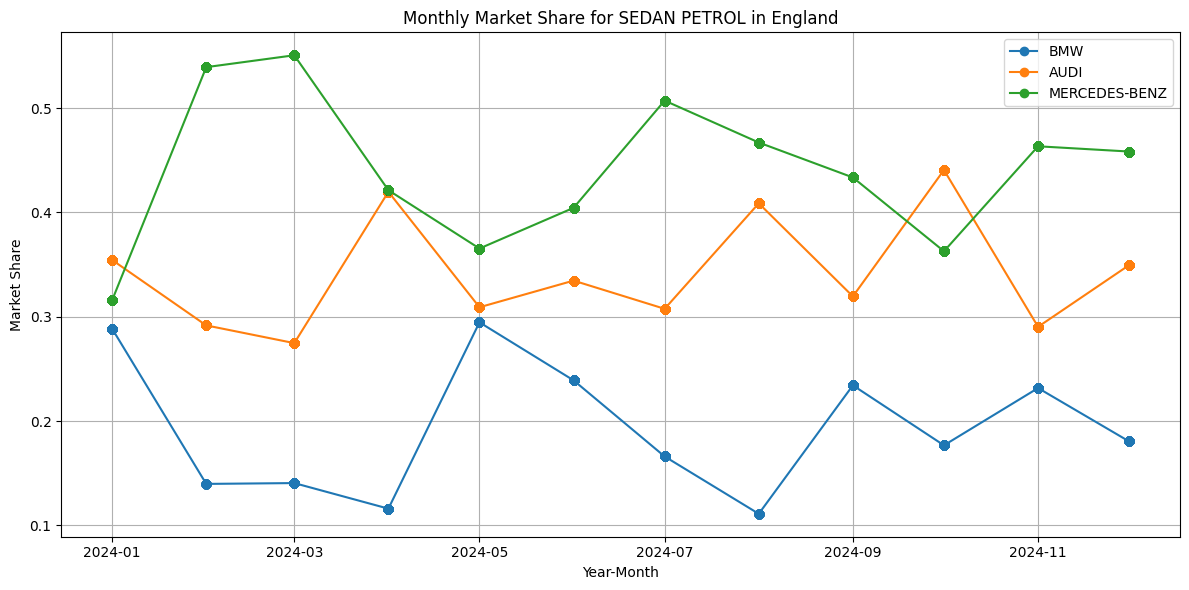

In [85]:
# Filter for BMW, AUDI, MERCEDES-BENZ, SEDAN, PETROL in England
oems = ['BMW', 'AUDI', 'MERCEDES-BENZ']
df_plot_multi = fact_market_share_country[
    (fact_market_share_country['oem'].isin(oems)) &
    (fact_market_share_country['body_type'] == 'SEDAN') &
    (fact_market_share_country['fuel_type'] == 'PETROL') &
    (fact_market_share_country['level_0_country'] == 'England')
]

# Sort by year_month
df_plot_multi = df_plot_multi.sort_values('year_month')

plt.figure(figsize=(12, 6))
for oem in oems:
    df_oem = df_plot_multi[df_plot_multi['oem'] == oem]
    plt.plot(df_oem['year_month'], df_oem['market_share_country'], marker='o', label=oem)

plt.title('Monthly Market Share for SEDAN PETROL in England')
plt.xlabel('Year-Month')
plt.ylabel('Market Share')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()